========== DATASET ==========
First 5 Rows:
   age  gender  fever  cough  headache  fatigue  body_pain  sore_throat  \
0   80  Female      0      0         1        1          0            0   
1   52  Female      1      0         1        1          1            1   
2   77  Female      1      1         1        1          0            1   
3   54    Male      1      0         1        0          1            1   
4   60    Male      1      0         1        1          1            1   

   runny_nose  sneezing  ...  joint_pain  breathing_difficulty  chest_pain  \
0           0         0  ...           0                     0           0   
1           0         0  ...           0                     0           0   
2           1         1  ...           0                     0           0   
3           0         1  ...           0                     0           0   
4           0         0  ...           1                     0           1   

   dizziness  skin_rash  loss_of_app

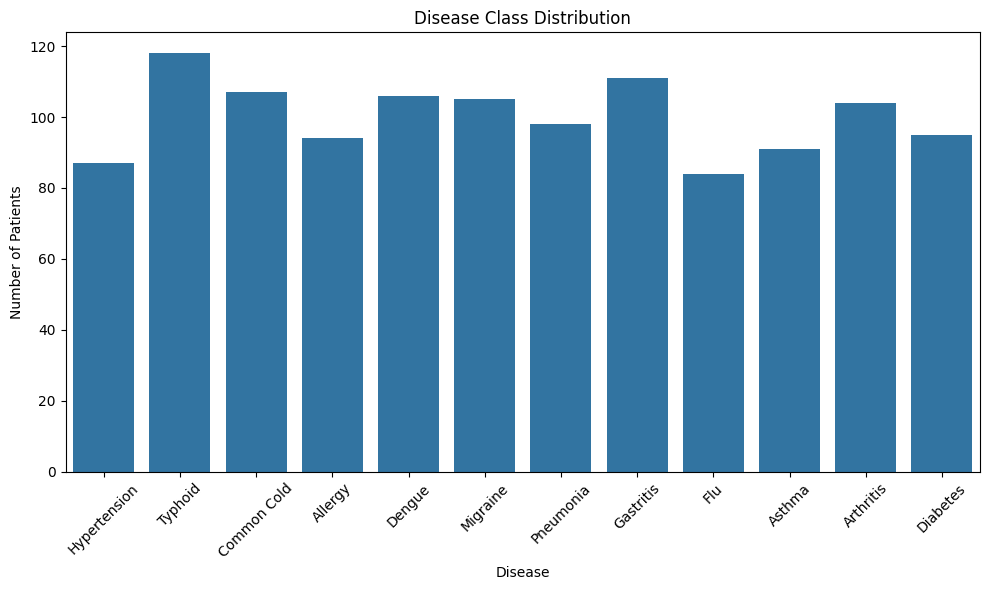


========== DISEASE LABELS ==========
0 = Allergy
1 = Arthritis
2 = Asthma
3 = Common Cold
4 = Dengue
5 = Diabetes
6 = Flu
7 = Gastritis
8 = Hypertension
9 = Migraine
10 = Pneumonia
11 = Typhoid

Feature Shape: (1200, 22)
Target Shape: (1200,)

========== TRAIN TEST SPLIT ==========
Training Samples: 960
Testing Samples: 240

========== MODEL TRAINING ==========
Multinomial Logistic Regression Model Trained Successfully!

========== MODEL PERFORMANCE ==========
Accuracy: 95.83 %

========== CLASSIFICATION REPORT ==========
              precision    recall  f1-score   support

     Allergy       1.00      1.00      1.00        19
   Arthritis       0.91      0.95      0.93        21
      Asthma       0.94      0.94      0.94        18
 Common Cold       0.95      1.00      0.98        21
      Dengue       1.00      1.00      1.00        21
    Diabetes       1.00      1.00      1.00        19
         Flu       1.00      1.00      1.00        17
   Gastritis       1.00      0.95     

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


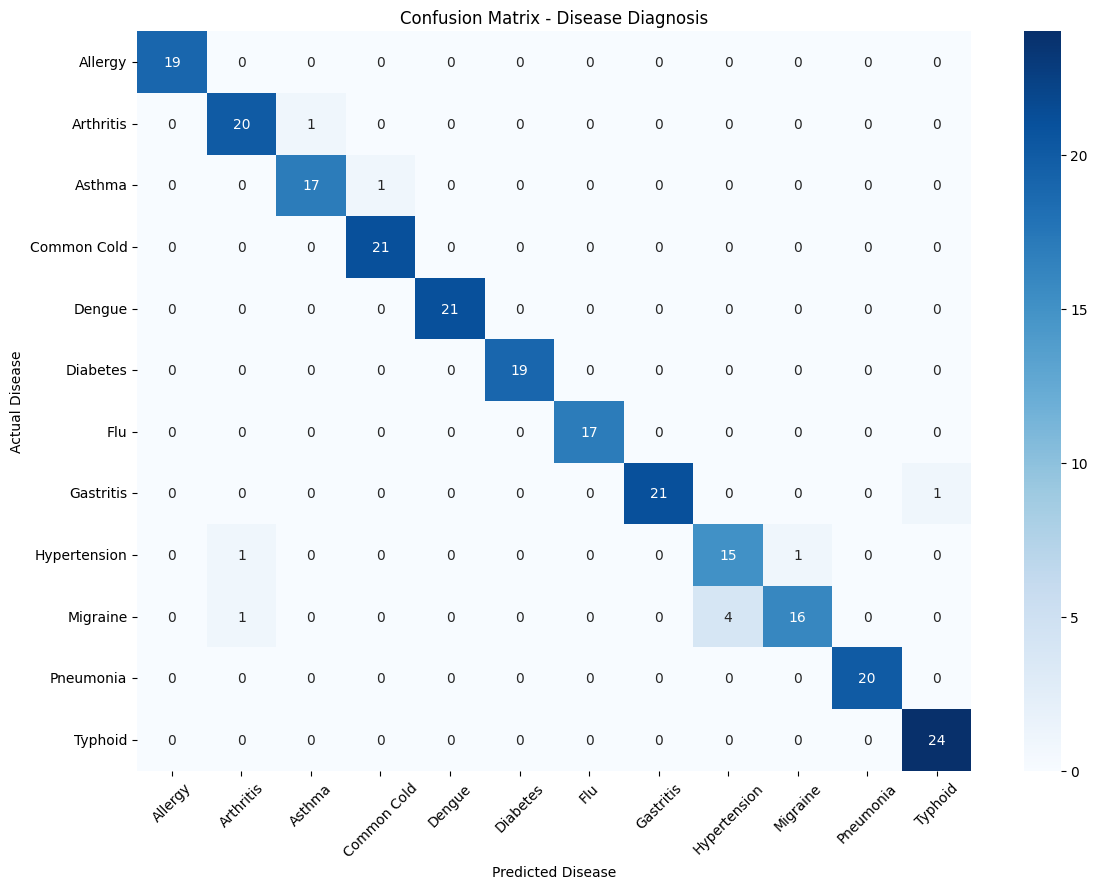


========== ACTUAL VS PREDICTED ==========
   Actual Disease Predicted Disease
0          Asthma            Asthma
1        Migraine          Migraine
2       Arthritis         Arthritis
3       Arthritis         Arthritis
4          Asthma            Asthma
5        Diabetes          Diabetes
6       Arthritis         Arthritis
7       Pneumonia         Pneumonia
8       Gastritis         Gastritis
9          Asthma            Asthma
10       Migraine          Migraine
11      Arthritis         Arthritis
12       Diabetes          Diabetes
13            Flu               Flu
14         Asthma            Asthma
15      Gastritis         Gastritis
16   Hypertension      Hypertension
17         Asthma            Asthma
18    Common Cold       Common Cold
19    Common Cold       Common Cold

========== SAMPLE PREDICTION PROBABILITIES ==========

Patient 1
Allergy : 0.74 %
Arthritis : 0.22 %
Asthma : 90.3 %
Common Cold : 0.0 %
Dengue : 0.0 %
Diabetes : 0.01 %
Flu : 0.11 %
Gastritis : 0.03 

In [2]:
# ============================================================
# MULTI-CLASS DISEASE DIAGNOSIS USING
# MULTINOMIAL LOGISTIC REGRESSION
# ============================================================

# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# ============================================================
# 2. Load Dataset
# ============================================================

df = pd.read_csv("multiclass_disease_diagnosis_1200.csv")

print("========== DATASET ==========")
print("First 5 Rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

# ============================================================
# 3. Basic Dataset Information
# ============================================================

print("\n========== DATASET INFORMATION ==========")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nTotal Missing Values:")
print(df.isnull().sum().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

# ============================================================
# 4. Disease Distribution
# ============================================================

print("\n========== DISEASE DISTRIBUTION ==========")
print(df["disease"].value_counts())

plt.figure(figsize=(10, 6))
sns.countplot(data=df, x="disease")
plt.title("Disease Class Distribution")
plt.xlabel("Disease")
plt.ylabel("Number of Patients")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ============================================================
# 5. Encode Gender
# ============================================================

df["gender"] = df["gender"].map({
    "Male": 0,
    "Female": 1
})

# ============================================================
# 6. Encode Target Disease
# ============================================================

label_encoder = LabelEncoder()

df["disease_encoded"] = label_encoder.fit_transform(df["disease"])

print("\n========== DISEASE LABELS ==========")

for i, disease in enumerate(label_encoder.classes_):
    print(i, "=", disease)

# ============================================================
# 7. Separate Features and Target
# ============================================================

X = df.drop(columns=["disease", "disease_encoded"])
y = df["disease_encoded"]

print("\nFeature Shape:", X.shape)
print("Target Shape:", y.shape)

# ============================================================
# 8. Train-Test Split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\n========== TRAIN TEST SPLIT ==========")
print("Training Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])

# ============================================================
# 9. Feature Scaling
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ============================================================
# 10. Multinomial Logistic Regression Model
# ============================================================

model = LogisticRegression(
    multi_class="multinomial",
    solver="lbfgs",
    max_iter=1000,
    random_state=42
)

model.fit(X_train_scaled, y_train)

print("\n========== MODEL TRAINING ==========")
print("Multinomial Logistic Regression Model Trained Successfully!")

# ============================================================
# 11. Prediction
# ============================================================

y_pred = model.predict(X_test_scaled)

# ============================================================
# 12. Accuracy
# ============================================================

accuracy = accuracy_score(y_test, y_pred)

print("\n========== MODEL PERFORMANCE ==========")
print("Accuracy:", round(accuracy * 100, 2), "%")

# ============================================================
# 13. Classification Report
# ============================================================

print("\n========== CLASSIFICATION REPORT ==========")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_
    )
)

# ============================================================
# 14. Confusion Matrix
# ============================================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(12, 9))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Confusion Matrix - Disease Diagnosis")
plt.xlabel("Predicted Disease")
plt.ylabel("Actual Disease")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# ============================================================
# 15. Actual vs Predicted
# ============================================================

comparison = pd.DataFrame({
    "Actual Disease": label_encoder.inverse_transform(y_test),
    "Predicted Disease": label_encoder.inverse_transform(y_pred)
})

print("\n========== ACTUAL VS PREDICTED ==========")
print(comparison.head(20))

# ============================================================
# 16. Prediction Probabilities
# ============================================================

probabilities = model.predict_proba(X_test_scaled)

print("\n========== SAMPLE PREDICTION PROBABILITIES ==========")

for i in range(5):
    print("\nPatient", i + 1)

    for j, disease in enumerate(label_encoder.classes_):
        print(
            disease,
            ":",
            round(probabilities[i][j] * 100, 2),
            "%"
        )

# ============================================================
# 17. Test a New Patient
# ============================================================

print("\n========== NEW PATIENT PREDICTION ==========")

# Example patient
# Order must match the feature columns
new_patient = pd.DataFrame([{
    "age": 35,
    "gender": 0,
    "fever": 1,
    "cough": 1,
    "headache": 1,
    "fatigue": 1,
    "body_pain": 1,
    "sore_throat": 1,
    "runny_nose": 0,
    "sneezing": 0,
    "nausea": 0,
    "vomiting": 0,
    "stomach_pain": 0,
    "joint_pain": 0,
    "breathing_difficulty": 0,
    "chest_pain": 0,
    "dizziness": 0,
    "skin_rash": 0,
    "loss_of_appetite": 1,
    "high_thirst": 0,
    "frequent_urination": 0,
    "wheezing": 0
}])

# Scale new patient
new_patient_scaled = scaler.transform(new_patient)

# Predict
prediction = model.predict(new_patient_scaled)

# Convert number back to disease name
predicted_disease = label_encoder.inverse_transform(prediction)

print("Predicted Disease:", predicted_disease[0])

# ============================================================
# 18. Prediction Probability for New Patient
# ============================================================

new_probabilities = model.predict_proba(new_patient_scaled)[0]

probability_table = pd.DataFrame({
    "Disease": label_encoder.classes_,
    "Probability": new_probabilities * 100
})

probability_table = probability_table.sort_values(
    by="Probability",
    ascending=False
)

print("\n========== DISEASE PROBABILITIES ==========")
print(probability_table.to_string(index=False))

# ============================================================
# 19. Final Summary
# ============================================================

print("\n==========================================")
print("       FINAL PROJECT SUMMARY")
print("==========================================")

print("Total Patients:", len(df))
print("Number of Features:", X.shape[1])
print("Number of Disease Classes:", len(label_encoder.classes_))
print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))
print("Model: Multinomial Logistic Regression")
print("Accuracy:", round(accuracy * 100, 2), "%")

print("\nDisease Classes:")
for disease in label_encoder.classes_:
    print("-", disease)

print("\nModel Execution Completed Successfully!")